<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/3_2_M%C3%A9todos_de_selecci%C3%B3n_de_variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 3: Modelos predictivos</header1></left>

### Paquetes usados

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style= 'whitegrid', context='notebook')



# Métodos de selección de variables

En el desarrollo de modelos supervisados —ya sean de regresión o clasificación— la selección de variables juega un papel crucial tanto en el rendimiento como en la interpretabilidad del modelo. Es común pensar que incluir más variables puede mejorar la precisión del modelo, pero esta suposición no siempre se cumple. D*e hecho, en muchos casos, un modelo con menos variables puede ofrecer resultados similares —o incluso mejores— que uno más complejo.*

**Complejidad vs. parsimonia**

Supongamos que tenemos dos modelos:

- Uno con 7 variables que clasifica con un 90% de precisión.

- Otro con 3 variables que también alcanza una precisión cercana al 90%.

En este caso, el modelo con 3 variables es preferible por varias razones:

+ Más simple de interpretar y comunicar: especialmente en contextos donde el modelo debe ser explicado a personas no técnicas (stakeholders, médicos, gerentes, etc.).

+ Más eficiente computacionalmente: menos variables implican menos carga de procesamiento, lo cual es útil en sistemas en tiempo real o con recursos limitados.

+ Menor riesgo de sobreajuste: más variables aumentan el riesgo de capturar ruido del entrenamiento en lugar de patrones reales.

**¿Más variables = más información?**

*Agregar variables adicionales solo es útil si aportan información nueva y significativa.* A veces, nuevas variables están altamente correlacionadas con otras ya incluidas, o simplemente no están relacionadas con la variable objetivo. *En esos casos, no solo no aportan valor, sino que pueden degradar el modelo introduciendo ruido y complejidad innecesaria.*

## Selección de variables y p-valor

En modelos estadísticos como la regresión lineal o logística, el p-valor asociado a cada variable permite evaluar si su efecto sobre la variable objetivo es estadísticamente significativo. Esta idea sirve de base para múltiples métodos de selección de variables:

- All-in (todos dentro): Se incluyen todas las variables disponibles, sin filtro. Es útil solo cuando hay una fuerte justificación teórica y pocos predictores, pero puede llevar a sobreajuste y multicolinealidad.

- Eliminación hacia atrás (backward elimination): Se parte del modelo completo y se eliminan sucesivamente las variables con p-valores más altos (menos significativas), hasta que todas las variables remanentes sean estadísticamente relevantes. Este enfoque favorece la parsimonia, pero puede ser ineficiente si hay muchas variables irrelevantes.

- Selección hacia adelante (forward selection): Parte de un modelo vacío y agrega variables una por una, seleccionando en cada paso la que más mejora el modelo (basado en p-valor o score). Es útil cuando hay muchas variables disponibles.

- Eliminación bidireccional (stepwise): Combina los dos enfoques anteriores, agregando y eliminando variables de forma iterativa. Es uno de los más usados en contextos estadísticos.

- Fuerza bruta = Comparación de scores (AIC, BIC, R² ajustado, etc.): Se comparan modelos alternativos en función de métricas que balancean el ajuste y la complejidad. Estas métricas penalizan el exceso de variables, favoreciendo modelos que expliquen bien los datos sin sobreajuste.

## Ejemplo [Insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance) (Regresión)

Para comenzar, definamos este concepto estadístico:

**Verosimilitud:** La verosimilitud (o likelihood en inglés) nos dice qué tan bien un modelo con parámetros específicos explica los datos que observamos.

*Ejemplo:*
Suponga que tiene un dado y lo lanzas 10 veces, obteniendo esta secuencia:
6, 6, 6, 5, 6, 6, 4, 6, 6, 6

Ahora imagina dos modelos:

- Modelo A: el dado es justo (todas las caras tienen probabilidad 1/6)
- Modelo B: el dado es cargado y tiene 80% de probabilidad de caer en 6

La verosimilitud es una forma de medir cuál de los dos modelos hace más probable observar esta secuencia de resultados. En este caso, claramente el Modelo B tiene mayor verosimilitud, porque explica mejor la frecuencia alta de 6.

**Métricas a considerar en una regresión (asociadas a verosimilitud)**

- AIC (Criterio de Información de Akaike) es una métrica que se usa para comparar modelos estadísticos. Mide el balance entre el ajuste del modelo y su complejidad. Penaliza los modelos que usan más parámetros para evitar el sobreajuste.

  - Fórmula simplificada:
  $$AIC=2𝑘−2 \ln (𝐿),$$ donde $𝑘$ es el número de parámetros del modelo y $L$ es la verosimilitud máxima del modelo.

  - Cuanto menor sea el AIC, mejor el modelo (mejor ajuste con menos complejidad).

- BIC (Criterio de Información Bayesiano) es similar al AIC, pero penaliza más fuertemente los modelos complejos, especialmente cuando el tamaño de muestra es grande.

  - Fórmula simplificada: $$ BIC = \ln(n) k − 2 \ln (L), $$ donde  $n$ es el número de observaciones,   $k$ el número de parámetros y   $L$ la verosimilitud.

  - También se busca un BIC más bajo, pero será más estricto con modelos con muchos parámetros.

In [ ]:
# paquetes usados
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# metricas
import sklearn.metrics as metrics
import statsmodels.api as sm

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(f"{path}/insurance.csv")

In [ ]:
#El paquete regressors tuvo muschos problemas, fue necesario incluir lo siguiente:
!pip install setuptools==58
!pip install regressors

  Using cached regressors-0.0.3-py2.py3-none-any.whl


In [ ]:
from regressors import stats

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The columns are:

- age: age of primary beneficiary

- sex: insurance contractor gender, female, male

- bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

- children: Number of children covered by health insurance / Number of dependents

- smoker: Smoking

- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

- charges: Individual medical costs billed by health insurance

En nuestro caso vamos a optar por trabajar con datos menores a 50.000, todo esto por analizar las tendencias de los valores no atípicos, no quiere decir que los valores observados arriba no sean interesantes, sólo que por nuestra finalidad explicitamente práctica vamos a trabajar valores menores a 50.000

<Axes: >

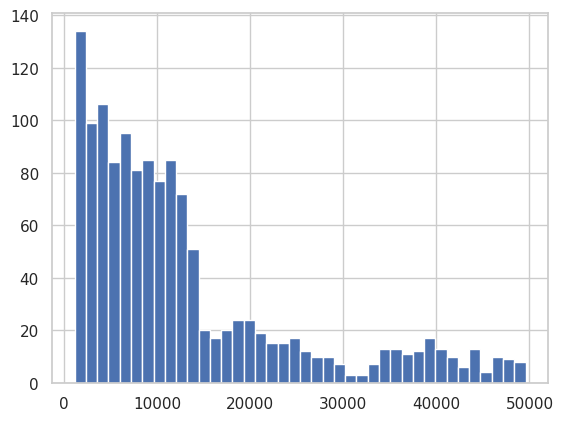

In [ ]:
df_1 = df[df.charges < 50000]
df_1.charges.hist(bins=40)

Para comenzar vamos a realizar el análisis de correlaciones

Aquí se observan varias correlaciones interesantes, entre ellas la distribución normal de BMI y la relación entre charges y age que admite 3 relaciones lineales si se admitealguna clasificación a tener en cuenta.

Vamos a trabajar con las variables númericas para analizar las correlaciones mas interesantes.

In [ ]:
df_1 = pd.get_dummies(df_1, columns=['sex', 'smoker', 'region'], drop_first= True)
df_1 = df_1.astype(int) # para que sean 0s y 1s
df_1.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


### All in

Para comenzar definimos las variables y datos necesarios para el modelo predictorio

In [ ]:
X_cols = list(set(df_1.columns) - set(['charges']))
y_col = ['charges']

X= df_1[X_cols].values
y= df_1[y_col].values

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
sc_x = StandardScaler().fit(X)
sc_y = StandardScaler().fit(y)

X_train_1 = sc_x.transform(X_train)
X_test_1 = sc_x.transform(X_test)
y_train_1 = sc_y.transform(y_train)
y_test_1 = sc_y.transform(y_test)

model_ai = LinearRegression()
model_ai.fit(X_train_1, y_train_1)
y_pred_1 = model_ai.predict(X_test_1)

In [ ]:
model_ai.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [ ]:
model_ai.score

<bound method RegressorMixin.score of LinearRegression()>

Vamos a crear las funciones que nos permitirán evaluar nuestro modelo, es decir, las métricas

In [ ]:
mse_ai = metrics.mean_squared_error(y_test_1,y_pred_1)
r2_ai = metrics.r2_score(y_test_1, y_pred_1)

print('r2: ', r2_ai)
print('mse: ', mse_ai)

r2:  0.7637575387234266
mse:  0.25582912976062605


In [ ]:
model_ai.intercept_ = model_ai.intercept_[0]
model_ai.coef_ = model_ai.coef_.reshape(-1)

In [ ]:
y_test_1 = y_test_1.reshape(-1)

print('======Summary=====')
stats.summary(model_ai, X_test_1, y_test_1, X_cols)

======Summary=====
Residuals:
    Min     1Q  Median     3Q    Max
-2.0231 -0.084  0.1088 0.2233 0.9667


Coefficients:
                  Estimate  Std. Error  t value   p value
_intercept        0.001863    0.027864   0.0669  0.946723
region_northwest -0.017536    0.031014  -0.5654  0.572157
children          0.060765    0.028555   2.1280  0.034077
sex_male          0.001447    0.027931   0.0518  0.958705
smoker_yes        0.789097    0.026713  29.5398  0.000000
region_southeast -0.047157    0.034679  -1.3598  0.174812
age               0.309527    0.028172  10.9870  0.000000
region_southwest -0.044809    0.032441  -1.3812  0.168138
bmi               0.142626    0.028168   5.0633  0.000001
---
R-squared:  0.76376,    Adjusted R-squared:  0.75792
F-statistic: 130.93 on 8 features


Otra forma de ver esto es con OLS

In [ ]:
X_test_sm = sm.add_constant(X_test_1)
modelo_sm = sm.OLS(y_test_1, X_test_sm).fit()

# Resumen estadístico
print('====== Resumen OLS ======')
print(modelo_sm.summary(xname=['const'] + X_cols))

====== Resumen OLS ======
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     139.5
Date:                Tue, 19 May 2026   Prob (F-statistic):          3.80e-100
Time:                        01:58:06   Log-Likelihood:                -237.38
No. Observations:                 333   AIC:                             492.8
Df Residuals:                     324   BIC:                             527.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const         

### Backward elimination


El backward elimination inicia con el caso all in, y hacemos estos pasos:

- Seleccionar un nivel de significancia, ejemplo $\alpha=95 \% $.
- Se calcula el modelo con todas las posibles variables predictoras.
- Consideramos la variable predictora con p-valor más grande que supere el nivel de significancia, y se hace lo siguiente:
  - Si existe, se elimina de las variables predictoras, y repite.
  - Si no existe, finaliza el modelo.

En nuestro caso, eliminamos 'sex_male'.

In [ ]:
X_cols = list(set(df_1.columns) - set(['charges', 'sex_male']))
y_col = ['charges']

X= df_1[X_cols].values
y= df_1[y_col].values

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
sc_x = StandardScaler().fit(X)
sc_y = StandardScaler().fit(y)

X_train_2 = sc_x.transform(X_train)
X_test_2 = sc_x.transform(X_test)
y_train_2 = sc_y.transform(y_train)
y_test_2 = sc_y.transform(y_test)

model_bp = LinearRegression()
model_bp.fit(X_train_2, y_train_2)
y_pred_2 = model_bp.predict(X_test_2)

In [ ]:
model_bp.intercept_ = model_bp.intercept_[0]
model_bp.coef_ = model_bp.coef_.reshape(-1)

In [ ]:
y_test_2 = y_test_2.reshape(-1)

print('======Summary=====')
stats.summary(model_bp, X_test_2, y_test_2, X_cols)

======Summary=====
Residuals:
    Min      1Q  Median     3Q    Max
-2.0218 -0.0834  0.1086 0.2247 0.9683


Coefficients:
                  Estimate  Std. Error  t value   p value
_intercept        0.001867    0.027860   0.0670  0.946609
region_northwest -0.017528    0.030996  -0.5655  0.572107
children          0.060771    0.028519   2.1309  0.033833
smoker_yes        0.789200    0.026634  29.6318  0.000000
region_southeast -0.047156    0.034667  -1.3603  0.174671
age               0.309498    0.028145  10.9964  0.000000
region_southwest -0.044827    0.032436  -1.3820  0.167894
bmi               0.142694    0.028107   5.0769  0.000001
---
R-squared:  0.76382,    Adjusted R-squared:  0.75873
F-statistic: 150.15 on 7 features


Eliminamos 'region_northwest'

In [ ]:
X_cols = list(set(df_1.columns) - set(['charges', 'sex_male', 'region_northwest']))
y_col = ['charges']

X= df_1[X_cols].values
y= df_1[y_col].values

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
sc_x = StandardScaler().fit(X)
sc_y = StandardScaler().fit(y)

X_train_2 = sc_x.transform(X_train)
X_test_2 = sc_x.transform(X_test)
y_train_2 = sc_y.transform(y_train)
y_test_2 = sc_y.transform(y_test)

model_bp = LinearRegression()
model_bp.fit(X_train_2, y_train_2)
y_pred_2 = model_bp.predict(X_test_2)

In [ ]:
model_bp.intercept_ = model_bp.intercept_[0]
model_bp.coef_ = model_bp.coef_.reshape(-1)

y_test_2 = y_test_2.reshape(-1)

print('======Summary=====')
stats.summary(model_bp, X_test_2, y_test_2, X_cols)

======Summary=====
Residuals:
   Min      1Q  Median     3Q    Max
-2.022 -0.0813  0.1061 0.2274 0.9489


Coefficients:
                  Estimate  Std. Error  t value   p value
_intercept        0.002072    0.027843   0.0744  0.940726
children          0.060491    0.028487   2.1235  0.034451
smoker_yes        0.789758    0.026636  29.6496  0.000000
region_southeast -0.038304    0.031313  -1.2233  0.222102
age               0.309481    0.028147  10.9952  0.000000
region_southwest -0.036222    0.029276  -1.2373  0.216868
bmi               0.142813    0.028090   5.0841  0.000001
---
R-squared:  0.76376,    Adjusted R-squared:  0.75941
F-statistic: 175.66 on 6 features


Ahora se elimina region_southeast

In [ ]:
X_cols = list(set(df_1.columns) - set(['charges', 'sex_male', 'region_northwest', 'region_southeast']))
y_col = ['charges']

X= df_1[X_cols].values
y= df_1[y_col].values

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
sc_x = StandardScaler().fit(X)
sc_y = StandardScaler().fit(y)

X_train_2 = sc_x.transform(X_train)
X_test_2 = sc_x.transform(X_test)
y_train_2 = sc_y.transform(y_train)
y_test_2 = sc_y.transform(y_test)

model_bp = LinearRegression()
model_bp.fit(X_train_2, y_train_2)
y_pred_2 = model_bp.predict(X_test_2)

In [ ]:
model_bp.intercept_ = model_bp.intercept_[0]
model_bp.coef_ = model_bp.coef_.reshape(-1)

y_test_2 = y_test_2.reshape(-1)

print('======Summary=====')
stats.summary(model_bp, X_test_2, y_test_2, X_cols)

======Summary=====
Residuals:
    Min      1Q  Median   3Q    Max
-1.9559 -0.0819  0.1112 0.23 1.0048


Coefficients:
                  Estimate  Std. Error  t value   p value
_intercept        0.001095    0.027718   0.0395  0.968514
children          0.060722    0.028404   2.1378  0.033262
smoker_yes        0.787120    0.026568  29.6263  0.000000
age               0.310379    0.028006  11.0827  0.000000
region_southwest -0.022627    0.028015  -0.8077  0.419850
bmi               0.132583    0.026855   4.9370  0.000001
---
R-squared:  0.76473,    Adjusted R-squared:  0.76113
F-statistic: 212.58 on 5 features


Se elimina region_southwest

In [ ]:
X_cols = list(set(df_1.columns) - set(['charges', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest']))
y_col = ['charges']

X= df_1[X_cols].values
y= df_1[y_col].values

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
sc_x = StandardScaler().fit(X)
sc_y = StandardScaler().fit(y)

X_train_2 = sc_x.transform(X_train)
X_test_2 = sc_x.transform(X_test)
y_train_2 = sc_y.transform(y_train)
y_test_2 = sc_y.transform(y_test)

model_bp = LinearRegression()
model_bp.fit(X_train_2, y_train_2)
y_pred_2 = model_bp.predict(X_test_2)

In [ ]:
model_bp.intercept_ = model_bp.intercept_[0]
model_bp.coef_ = model_bp.coef_.reshape(-1)

y_test_2 = y_test_2.reshape(-1)

print('======Summary=====')
stats.summary(model_bp, X_test_2, y_test_2, X_cols)

======Summary=====
Residuals:
    Min     1Q  Median     3Q   Max
-1.9684 -0.074  0.1029 0.2205 0.993


Coefficients:
            Estimate  Std. Error  t value   p value
_intercept  0.000972    0.027698   0.0351  0.972027
children    0.059893    0.028382   2.1102  0.035585
smoker_yes  0.788060    0.026545  29.6877  0.000000
age         0.310180    0.027989  11.0823  0.000000
bmi         0.132665    0.026837   4.9433  0.000001
---
R-squared:  0.76500,    Adjusted R-squared:  0.76214
F-statistic: 266.94 on 4 features


Para finalizar miremos algunas métricas

In [ ]:
mse_bp = metrics.mean_squared_error(y_test_2,y_pred_2)
r2_bp = metrics.r2_score(y_test_2, y_pred_2)

print('r2 all in: ', r2_ai)
print('r2 bp: ', r2_bp)
print('mse all in: ', mse_ai)
print('mse bp: ', mse_bp)

r2 all in:  0.7637575387234266
r2 bp:  0.765001502979445
mse all in:  0.25582912976062605
mse bp:  0.25448202944956916


### Forward selection

El forward selection inicia con el caso all in, y hacemos estos pasos:

- Seleccionar un nivel de significancia, ejemplo $\alpha=95 \%$.
- Se calculan todos los modelos de regresión simple posibles (es decir, con todas las variables). De ahí elegimos la variable con el de menor p-valor.
- Se calculan todos los modelos de regresión posibles de 2 variables, en odnde una de esas es la seleccionada previamente. De ahí elegimos la variable con el de menor p-valor en la variable añadida que so supere el nivel de significancia.
- Se repite hasta que no exista variable para agregar.


In [ ]:
df_1.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

Creamos la función para esto, pero solo traemos el OLS

In [ ]:
def entrenar_modelo_por_variable(df, y_col='charges', X_usar=[]):
    variables_disponibles = ['age', 'bmi', 'children', 'charges',
                             'sex_male', 'smoker_yes',
                             'region_northwest', 'region_southeast', 'region_southwest']

    resultados = {}

    for var in variables_disponibles:
        if var not in X_usar and var != y_col:
            X_cols = X_usar + [var]
            X = df[X_cols].values
            y = df[[y_col]].values

            X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

            sc_x = StandardScaler().fit(X_train)
            sc_y = StandardScaler().fit(y_train)

            X_train_1 = sc_x.transform(X_train)
            X_test_1 = sc_x.transform(X_test)
            y_train_1 = sc_y.transform(y_train)
            y_test_1 = sc_y.transform(y_test)

            model = LinearRegression()
            model.fit(X_train_1, y_train_1)
            y_pred_1 = model.predict(X_test_1)

            model.intercept_ = np.array([model.intercept_[0]])
            model.coef_ = model.coef_.reshape(-1)

            y_test_1 = y_test_1.reshape(-1)

            print(f'\n====== Summary usando variable: {var} ======')
            X_test_sm = sm.add_constant(X_test_1)
            modelo_sm = sm.OLS(y_test_1, X_test_sm).fit()
            p_values = modelo_sm.pvalues
            for var_name, p_val in zip(['const'] + X_cols, p_values):
                print(f'{var_name}: {p_val:.4f}')
            #print(modelo_sm.summary())


In [ ]:
entrenar_modelo_por_variable(df_1)


====== Summary usando variable: age ======
const: 0.2085
age: 0.0000

====== Summary usando variable: bmi ======
const: 0.3111
bmi: 0.0000

====== Summary usando variable: children ======
const: 0.2514
children: 0.1310

====== Summary usando variable: sex_male ======
const: 0.2587
sex_male: 0.2869

====== Summary usando variable: smoker_yes ======
const: 0.8248
smoker_yes: 0.0000

====== Summary usando variable: region_northwest ======
const: 0.2364
region_northwest: 0.4988

====== Summary usando variable: region_southeast ======
const: 0.2073
region_southeast: 0.0929

====== Summary usando variable: region_southwest ======
const: 0.2664
region_southwest: 0.5668


Vamos a seleccionar la variable age

In [ ]:
entrenar_modelo_por_variable(df_1, X_usar=['age'])


====== Summary usando variable: bmi ======
const: 0.2550
age: 0.0002
bmi: 0.0000

====== Summary usando variable: children ======
const: 0.2027
age: 0.0000
children: 0.1618

====== Summary usando variable: sex_male ======
const: 0.2070
age: 0.0000
sex_male: 0.1998

====== Summary usando variable: smoker_yes ======
const: 0.9237
age: 0.0000
smoker_yes: 0.0000

====== Summary usando variable: region_northwest ======
const: 0.1868
age: 0.0000
region_northwest: 0.4529

====== Summary usando variable: region_southeast ======
const: 0.1558
age: 0.0000
region_southeast: 0.0479

====== Summary usando variable: region_southwest ======
const: 0.2150
age: 0.0000
region_southwest: 0.5339


Elegimos smoker_yes

In [ ]:
entrenar_modelo_por_variable(df_1, X_usar=['age', 'smoker_yes'])


====== Summary usando variable: bmi ======
const: 0.7194
age: 0.0000
smoker_yes: 0.0000
bmi: 0.0000

====== Summary usando variable: children ======
const: 0.9324
age: 0.0000
smoker_yes: 0.0000
children: 0.4992

====== Summary usando variable: sex_male ======
const: 0.9222
age: 0.0000
smoker_yes: 0.0000
sex_male: 0.8381

====== Summary usando variable: region_northwest ======
const: 0.9962
age: 0.0000
smoker_yes: 0.0000
region_northwest: 0.2772

====== Summary usando variable: region_southeast ======
const: 0.9197
age: 0.0000
smoker_yes: 0.0000
region_southeast: 0.0209

====== Summary usando variable: region_southwest ======
const: 0.9180
age: 0.0000
smoker_yes: 0.0000
region_southwest: 0.7551


Agregamos bmi

In [ ]:
entrenar_modelo_por_variable(df_1, X_usar=['age', 'smoker_yes', 'bmi'])


====== Summary usando variable: children ======
const: 0.7325
age: 0.0000
smoker_yes: 0.0000
bmi: 0.0000
children: 0.2078

====== Summary usando variable: sex_male ======
const: 0.7122
age: 0.0000
smoker_yes: 0.0000
bmi: 0.0000
sex_male: 0.4148

====== Summary usando variable: region_northwest ======
const: 0.7199
age: 0.0000
smoker_yes: 0.0000
bmi: 0.0000
region_northwest: 0.9868

====== Summary usando variable: region_southeast ======
const: 0.7073
age: 0.0000
smoker_yes: 0.0000
bmi: 0.0000
region_southeast: 0.8535

====== Summary usando variable: region_southwest ======
const: 0.7157
age: 0.0000
smoker_yes: 0.0000
bmi: 0.0000
region_southwest: 0.8118


La selección esta hecha.

### Eliminación bidirecional

Es una combinación de los 2 anteriores.

- Se definen 2 niveles de significancia, SL-enter y SL-stay.
- Se hace selección hacía adelante con las variables que cumplan que su p-valor sea menor que SL-enter.
- De ahí se procede a hacer todos los pasos de eliminación hacía atrás con SL-stay.
- Se repite el ciclo hasta que no haya mejora.

Este tipo de estrategía es mejor hacerla automatizando. Manualmente puede ser tedioso.

### Fuerza bruta

Se crean todos los posibles modelos.

- Para $N$ variables hay $2^{N}-1$ posibles modelos.
- Se define una métrica
- Se elige el mejor modelo conforme a la métrica definida.

# Métodos de selección de hiperparámetros

Para más detalle ver: [¿Qué es el ajuste de hiperparámetros?](https://www.ibm.com/es-es/think/topics/hyperparameter-tuning)



El ajuste de hiperparámetros consiste en identificar y seleccionar los hiperparámetros óptimos para el entrenamiento de un modelo de aprendizaje automático. Cuando se realiza correctamente, el ajuste de hiperparámetros minimiza la función de pérdida de un modelo de aprendizaje automático, lo que significa que el rendimiento del modelo se entrena para ser lo más preciso posible.

En muchos modelos de aprendizaje supervisado (como regresión logística, árboles de decisión, SVM o redes neuronales), hay parámetros llamados hiperparámetros que no se aprenden directamente de los datos, sino que deben fijarse antes del entrenamiento. Por ejemplo: la profundidad de un árbol, la tasa de aprendizaje o la penalización en una regresión.

Una buena selección de hiperparámetros puede marcar la diferencia entre un modelo mediocre y uno de alto rendimiento. Para encontrar los valores óptimos, se utilizan distintas estrategias:

1. **Búsqueda en cuadrícula (Grid Search):**
Consiste en definir un conjunto fijo de valores posibles para cada hiperparámetro y luego entrenar el modelo con todas las combinaciones posibles.

2. **Búsqueda aleatoria (Random Search):**
En lugar de probar todas las combinaciones posibles, este método selecciona combinaciones aleatorias dentro de los rangos definidos para cada hiperparámetro.

3. **Optimización bayesiana (Bayesian Optimization):**
Este método utiliza modelos probabilísticos (por ejemplo, procesos de Gauss) para modelar el rendimiento del modelo según los hiperparámetros ya evaluados, y decide inteligentemente qué combinaciones probar a continuación.

## Ejemplo [Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (Clasificación)

Primero veremos el caso sin optimizar

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

In [ ]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df_data = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
# con este codigo vemos todas las cols
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
df_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#pasamos TotalCharges a numérico
df_data.TotalCharges = pd.to_numeric(df_data.TotalCharges, errors='coerce')

In [ ]:
df_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# En este caso eliminaremos los nulos
df_data.dropna(inplace=True)

In [ ]:
#eliminamos los id
df_data.drop('customerID',axis=1,inplace=True)

In [ ]:
#convertimos a numerico la var objetivo 'Churn'
df_data['Churn'].replace(to_replace='Yes', value = 1, inplace=True)
df_data['Churn'].replace(to_replace='No', value = 0, inplace=True)

/tmp/ipython-input-39-2314335517.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_data['Churn'].replace(to_replace='Yes', value = 1, inplace=True)
/tmp/ipython-input-39-2314335517.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

In [ ]:
df_data_processing = df_data.copy()

In [ ]:
#aplicamos el get-dummies
df_data_processing = pd.get_dummies(df_data_processing)
df_data_processing = df_data_processing.astype(int)
df_data_processing.sample(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3398,0,61,100,6018,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0
670,0,53,19,1039,0,1,0,0,1,0,1,0,1,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,1,0,0,0
423,0,44,25,1110,0,0,1,0,1,0,1,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1
3605,0,34,49,1734,0,0,1,1,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
4566,0,68,100,6754,0,0,1,0,1,1,0,0,1,1,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0


In [ ]:
scaler = MinMaxScaler()
df_data_processing_scaled =  scaler.fit_transform(df_data_processing)
df_data_processing_scaled = pd.DataFrame(df_data_processing_scaled)
df_data_processing_scaled.columns = df_data_processing.columns

In [ ]:
# Entrenamiento del modelo
X = df_data_processing_scaled.drop('Churn',axis=1)
y = df_data_processing_scaled['Churn'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

### Sin selección

In [ ]:
model_no = LogisticRegression()
result_no = model_no.fit(X_train, y_train)
prediction_test_no = model_no.predict(X_test)

In [ ]:
acuracy_no = accuracy_score(y_test,prediction_test_no)
# métricas en general
print("Accuracy: \n", acuracy_no)
print("\nClassification Report:\n", classification_report(y_test,prediction_test_no))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,prediction_test_no))

Accuracy: 
 0.8024164889836531

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1033
         1.0       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
 [[916 117]
 [161 213]]


### Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

def buscar_hiperparametros_logistica(X_train, y_train, scoring='f1', cv=5, verbose=1):
    """
    Realiza búsqueda de hiperparámetros con GridSearchCV para regresión logística.

    Parámetros:
    - X_train: variables predictoras de entrenamiento
    - y_train: variable objetivo de entrenamiento
    - scoring: métrica de evaluación (por defecto 'f1)
    - cv: número de folds para validación cruzada
    - verbose: nivel de impresión

    Retorna:
    - mejor_modelo: el modelo entrenado con los mejores hiperparámetros
    - grid_result: el objeto completo de GridSearchCV (para explorar resultados)
    """

    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']  # ambos soportan L1 y L2
    }

    modelo = LogisticRegression(max_iter=1000)
    grid_search = GridSearchCV(estimator=modelo, param_grid=param_grid,
                               scoring=scoring, cv=cv, verbose=verbose, n_jobs=-1)

    grid_search.fit(X_train, y_train)

    print("\nMejores parámetros encontrados:")
    print(grid_search.best_params_)
    print(f"Mejor puntuación ({scoring}): {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_, grid_search


In [ ]:
mejor_modelo, resultado_grid = buscar_hiperparametros_logistica(X_train, y_train)
y_pred = mejor_modelo.predict(X_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros encontrados:
{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación (f1): 0.5963


In [ ]:
acuracy_grid = accuracy_score(y_test,y_pred)
# métricas en general
print("Accuracy: \n", acuracy_grid)
print("\nClassification Report:\n", classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred))

Accuracy: 
 0.8052594171997157

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1033
         1.0       0.65      0.58      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407


Confusion Matrix:
 [[917 116]
 [158 216]]


### Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

def buscar_hiperparametros_logistica_random(X_train, y_train, scoring='f1', cv=5, verbose=1, n_iter=20, random_state=42):
    """
    Realiza búsqueda aleatoria de hiperparámetros para regresión logística.

    Parámetros:
    - X_train, y_train: datos de entrenamiento
    - scoring: métrica de evaluación (default: f1)
    - cv: número de folds de validación cruzada
    - verbose: nivel de impresión
    - n_iter: número de combinaciones aleatorias a probar
    - random_state: semilla para reproducibilidad

    Retorna:
    - mejor_modelo: modelo con los mejores hiperparámetros
    - resultado_random: objeto RandomizedSearchCV para explorar resultados
    """

    param_dist = {
        'C': loguniform(1e-4, 1e4),              # Escala logarítmica entre 0.0001 y 10000
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }

    modelo = LogisticRegression(max_iter=1000)

    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=verbose,
        random_state=random_state,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    print("\nMejores parámetros encontrados:")
    print(random_search.best_params_)
    print(f"Mejor puntuación ({scoring}): {random_search.best_score_:.4f}")

    return random_search.best_estimator_, random_search


In [ ]:
random_modelo, resultado_random = buscar_hiperparametros_logistica_random(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros encontrados:
{'C': np.float64(7.250347382396653), 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación (f1): 0.5958


In [ ]:
y_pred_random = random_modelo.predict(X_test)
acuracy_random = accuracy_score(y_test,y_pred_random)
# métricas en general
print("Accuracy: \n", acuracy_random)
print("\nClassification Report:\n", classification_report(y_test,y_pred_random))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_random))

Accuracy: 
 0.8045486851457001

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1033
         1.0       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
 [[917 116]
 [159 215]]


### Optimización bayesiana

In [ ]:
pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

def buscar_hiperparametros_logistica_bayesiana(X_train, y_train, scoring='f1', cv=5, n_iter=32, random_state=42, verbose=1):
    """
    Optimización bayesiana de hiperparámetros para regresión logística.

    Parámetros:
    - X_train, y_train: datos de entrenamiento
    - scoring: métrica de evaluación ('f1' por defecto)
    - cv: número de folds de validación cruzada
    - n_iter: número de iteraciones de búsqueda
    - random_state: para reproducibilidad
    - verbose: nivel de impresión

    Retorna:
    - mejor_modelo: el modelo entrenado con mejores hiperparámetros
    - resultado_bayes: el objeto BayesSearchCV completo
    """

    search_spaces = {
        'C': Real(1e-4, 1e4, prior='log-uniform'),
        'penalty': Categorical(['l1', 'l2']),
        'solver': Categorical(['liblinear', 'saga'])  # Ambos soportan L1 y L2
    }

    modelo = LogisticRegression(max_iter=1000)

    opt_bayes = BayesSearchCV(
        estimator=modelo,
        search_spaces=search_spaces,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=verbose,
        n_jobs=-1,
        random_state=random_state
    )

    opt_bayes.fit(X_train, y_train)

    print("\nMejores parámetros encontrados:")
    print(opt_bayes.best_params_)
    print(f"Mejor puntuación ({scoring}): {opt_bayes.best_score_:.4f}")

    return opt_bayes.best_estimator_, opt_bayes


In [ ]:
bay_modelo, resultado_bayes = buscar_hiperparametros_logistica_bayesiana(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
y_pred_bay = bay_modelo.predict(X_test)
acuracy_bay = accuracy_score(y_test,y_pred_bay)
# métricas en general
print("Accuracy: \n", acuracy_bay)
print("\nClassification Report:\n", classification_report(y_test,y_pred_bay))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred_bay))

Accuracy: 
 0.8031272210376688

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1033
         1.0       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
 [[917 116]
 [161 213]]
